In [1]:
!pip install pyspark

  Using cached pyspark-4.1.1-py2.py3-none-any.whl
  Using cached py4j-0.10.9.9-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached py4j-0.10.9.9-py2.py3-none-any.whl (203 kB)

   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------------------- 1/2 [pyspark]
   -------------------- ------

In [2]:
import sys
import time
import random
import numpy as np

from pyspark.sql import SparkSession
from pyspark.mllib.linalg import Vectors, Vector

In [3]:
# Create Spark session
import time
import random
from pyspark.mllib.linalg import Vectors

In [4]:
import time
import random
from pyspark.mllib.linalg import Vectors


def readVectorsSeq(filename):
    """
    Reads dataset and returns list of Spark dense vectors.
    Last column is label, so ignored.
    """
    points = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line == "":
                continue

            values = [float(x) for x in line.split(",")]
            features = values[:-1]   # ignore label column
            points.append(Vectors.dense(features))

    return points


def squared_distance(a, b):
    """
    Squared Euclidean distance between two vectors.
    """
    return sum((x - y) ** 2 for x, y in zip(a, b))


def min_squared_distance(point, centers):
    """
    Distance from point to nearest center.
    """
    min_dist = float("inf")
    for c in centers:
        dist = squared_distance(point, c)
        if dist < min_dist:
            min_dist = dist
    return min_dist


def kcenter(P, k):
    """
    Farthest-First Traversal for k-center clustering.
    """
    n = len(P)

    if k <= 0:
        return []

    if k >= n:
        return P.copy()

    C = [P[0]]
    min_dists = [squared_distance(P[i], C[0]) for i in range(n)]

    for _ in range(1, k):
        farthest_index = max(range(n), key=lambda i: min_dists[i])
        new_center = P[farthest_index]
        C.append(new_center)

        for i in range(n):
            dist = squared_distance(P[i], new_center)
            if dist < min_dists[i]:
                min_dists[i] = dist

    return C


def kmeansPP(P, k, seed=42):
    """
    k-means++ initialization.
    """
    random.seed(seed)
    n = len(P)

    if k <= 0:
        return []

    if k >= n:
        return P.copy()

    first_index = random.randint(0, n - 1)
    C = [P[first_index]]

    min_dists = [squared_distance(P[i], C[0]) for i in range(n)]

    for _ in range(1, k):
        total = sum(min_dists)

        if total == 0:
            break

        r = random.random() * total
        cumulative = 0.0
        chosen_index = 0

        for i, d in enumerate(min_dists):
            cumulative += d
            if cumulative >= r:
                chosen_index = i
                break

        new_center = P[chosen_index]
        C.append(new_center)

        for i in range(n):
            dist = squared_distance(P[i], new_center)
            if dist < min_dists[i]:
                min_dists[i] = dist

    return C


def kmeansObj(P, C):
    """
    Average squared distance from points to nearest center.
    """
    if len(P) == 0 or len(C) == 0:
        return 0.0

    total = 0.0
    for p in P:
        total += min_squared_distance(p, C)

    return total / len(P)


def runClusteringExperiment(filename, k, k1, seed=42):
    """
    Runs the 3 required assignment experiments.
    """
    if k >= k1:
        raise ValueError("Assignment requires k < k1")

    P = readVectorsSeq(filename)

    print("Number of points =", len(P))
    print("Dimension of each point =", len(P[0]))
    print("-" * 60)

    # 1. kcenter running time
    start_time = time.time()
    C_kcenter = kcenter(P, k)
    end_time = time.time()
    print(f"1. Running time of kcenter(P, {k}) = {end_time - start_time:.6f} seconds")

    # 2. kmeans++ objective
    C_kmeanspp = kmeansPP(P, k, seed=seed)
    obj_direct = kmeansObj(P, C_kmeanspp)
    print(f"2. kmeansObj(P, kmeansPP(P, {k})) = {obj_direct:.6f}")

    # 3. coreset experiment
    X = kcenter(P, k1)
    C_coreset = kmeansPP(X, k, seed=seed)
    obj_coreset = kmeansObj(P, C_coreset)
    print(f"3. kmeansObj(P, kmeansPP(kcenter(P, {k1}), {k})) = {obj_coreset:.6f}")

    return {
        "P": P,
        "C_kcenter": C_kcenter,
        "C_kmeanspp": C_kmeanspp,
        "X": X,
        "C_coreset": C_coreset,
        "obj_direct": obj_direct,
        "obj_coreset": obj_coreset
    }

In [5]:
# Example values
filename = r"C:\Users\hp\Downloads\Assignment 4- datasets-20260408T204937Z-3-001\Assignment 4- datasets\Q1- UCI Spam clustering\spambase.data"
k = 10
k1 = 50
results = runClusteringExperiment(filename, 10, 50, seed=42)

Number of points = 4601
Dimension of each point = 57
------------------------------------------------------------
1. Running time of kcenter(P, 10) = 4.678133 seconds
2. kmeansObj(P, kmeansPP(P, 10)) = 31250.987038
3. kmeansObj(P, kmeansPP(kcenter(P, 50), 10)) = 99261.564855


In [6]:
import sys

def main():
    """
    Command line usage:
    python part1_clustering.py spambase.data 10 50
    """
    if len(sys.argv) != 4:
        print("Usage: python part1_clustering.py <filename> <k> <k1>")
        return

    filename = sys.argv[1]
    k = int(sys.argv[2])
    k1 = int(sys.argv[3])

    runClusteringExperiment(filename, k, k1, seed=42)

# Uncomment below if running as .py file
# if __name__ == "__main__":
#     main()

In [7]:
"""for k1 in [20, 50, 100, 200]:
    print("\n" + "="*70)
    print(f"Running for k = 10 and k1 = {k1}")
    runClusteringExperiment(filename, 10, k1, seed=42)"""

'for k1 in [20, 50, 100, 200]:\n    print("\n" + "="*70)\n    print(f"Running for k = 10 and k1 = {k1}")\n    runClusteringExperiment(filename, 10, k1, seed=42)'

In [8]:
import time
import matplotlib.pyplot as plt

filename = r"C:\Users\hp\Downloads\Assignment 4- datasets-20260408T204937Z-3-001\Assignment 4- datasets\Q1- UCI Spam clustering\spambase.data"

k = 10
k1_values = [20, 50, 100, 200]

obj_direct_list = []
obj_coreset_list = []
kcenter_time_list = []
coreset_total_time_list = []

for k1 in k1_values:
    print("\n" + "="*70)
    print(f"Running for k = {k} and k1 = {k1}")

    start_total = time.time()
    results = runClusteringExperiment(filename, k, k1, seed=42)
    total_time = time.time() - start_total

    P = results["P"]
    start_kcenter = time.time()
    _ = kcenter(P, k1)
    kcenter_time = time.time() - start_kcenter

    obj_direct_list.append(results["obj_direct"])
    obj_coreset_list.append(results["obj_coreset"])
    kcenter_time_list.append(kcenter_time)
    coreset_total_time_list.append(total_time)

print("obj_direct_list   =", obj_direct_list)
print("obj_coreset_list  =", obj_coreset_list)
print("kcenter_time_list =", kcenter_time_list)
print("total_time_list   =", coreset_total_time_list)


Running for k = 10 and k1 = 20
Number of points = 4601
Dimension of each point = 57
------------------------------------------------------------
1. Running time of kcenter(P, 10) = 4.654048 seconds
2. kmeansObj(P, kmeansPP(P, 10)) = 31250.987038
3. kmeansObj(P, kmeansPP(kcenter(P, 20), 10)) = 72138.313177

Running for k = 10 and k1 = 50
Number of points = 4601
Dimension of each point = 57
------------------------------------------------------------
1. Running time of kcenter(P, 10) = 4.549731 seconds
2. kmeansObj(P, kmeansPP(P, 10)) = 31250.987038
3. kmeansObj(P, kmeansPP(kcenter(P, 50), 10)) = 99261.564855

Running for k = 10 and k1 = 100
Number of points = 4601
Dimension of each point = 57
------------------------------------------------------------
1. Running time of kcenter(P, 10) = 4.555110 seconds
2. kmeansObj(P, kmeansPP(P, 10)) = 31250.987038
3. kmeansObj(P, kmeansPP(kcenter(P, 100), 10)) = 745044.237333

Running for k = 10 and k1 = 200
Number of points = 4601
Dimension of eac

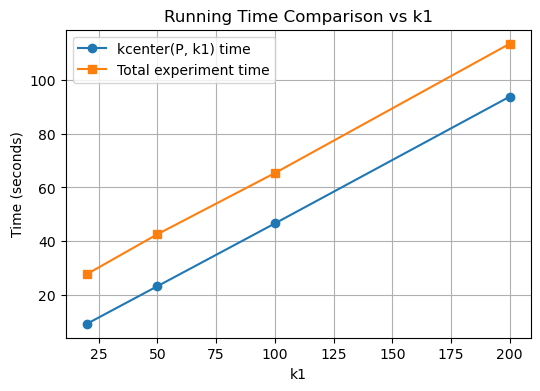

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(k1_values, kcenter_time_list, marker='o', label='kcenter(P, k1) time')
plt.plot(k1_values, coreset_total_time_list, marker='s', label='Total experiment time')
plt.xlabel("k1")
plt.ylabel("Time (seconds)")
plt.title("Running Time Comparison vs k1")
plt.legend()
plt.grid(True)
plt.show()

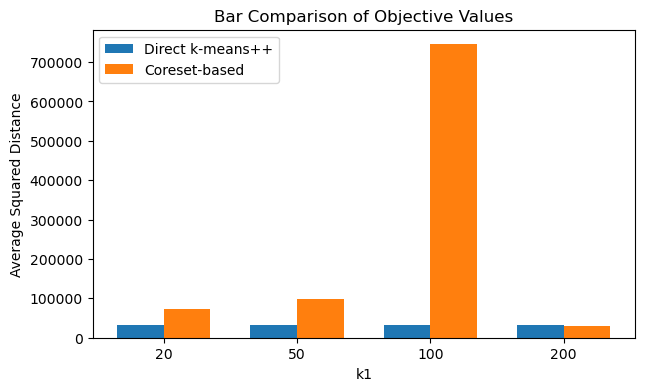

In [13]:
x = range(len(k1_values))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar([i - width/2 for i in x], obj_direct_list, width=width, label='Direct k-means++')
plt.bar([i + width/2 for i in x], obj_coreset_list, width=width, label='Coreset-based')
plt.xticks(list(x), k1_values)
plt.xlabel("k1")
plt.ylabel("Average Squared Distance")
plt.title("Bar Comparison of Objective Values")
plt.legend()
plt.show()

In [9]:
#### PART 2 ####

In [9]:
import os
import re
import math

In [10]:
# Connector words given in assignment
CONNECTOR_WORDS = {
    "a", "an", "the", "they", "these", "this", "for", "is", "are",
    "was", "of", "or", "and", "does", "will", "whose"
}

# Singular-plural normalization map
# We convert plural into the singular form
SINGULAR_MAP = {
    "stacks": "stack",
    "structures": "structure",
    "applications": "application"
}

def normalize_word(word):
    """
    Normalize a word according to assignment rules:
    - lowercase
    - remove punctuation-like symbols by keeping only letters/digits
    - map plural to singular where required
    """
    word = word.lower()

    # keep only alphanumeric characters
    # this also makes C++ become c
    word = re.sub(r'[^a-z0-9]', '', word)

    if word in SINGULAR_MAP:
        word = SINGULAR_MAP[word]

    return word

In [11]:
class MySet:
    """
    Simple custom set class used in the assignment.
    Internally implemented using Python dictionary to preserve uniqueness.
    """
    def __init__(self):
        self.data = {}

    def addElement(self, element):
        self.data[element] = True

    def union(self, otherSet):
        result = MySet()
        for x in self.data:
            result.addElement(x)
        for x in otherSet.data:
            result.addElement(x)
        return result

    def intersection(self, otherSet):
        result = MySet()
        for x in self.data:
            if x in otherSet.data:
                result.addElement(x)
        return result

    def getElements(self):
        return list(self.data.keys())

    def __iter__(self):
        return iter(self.data.keys())

    def __len__(self):
        return len(self.data)

In [12]:
class Position:
    """
    Represents <page, wordIndex>
    """
    def __init__(self, p, wordIndex):
        self.page = p
        self.wordIndex = wordIndex

    def getPageEntry(self):
        return self.page

    def getWordIndex(self):
        return self.wordIndex

In [13]:
class WordEntry:
    """
    Stores all positions where a word appears.
    """
    def __init__(self, word):
        self.word = word
        self.positions = []

    def addPosition(self, position):
        self.positions.append(position)

    def addPositions(self, positions):
        for p in positions:
            self.addPosition(p)

    def getAllPositionsForThisWord(self):
        return self.positions

    def getTermFrequency(self, word):
        """
        Term frequency inside a webpage word-entry context:
        frequency of word / total non-connector words in that page
        """
        if not self.positions:
            return 0.0

        page = self.positions[0].getPageEntry()
        freq = len(self.positions)
        total_words = page.total_indexed_words

        if total_words == 0:
            return 0.0

        return freq / total_words

In [14]:
class PageIndex:
    """
    Stores one WordEntry per unique word for a page.
    """
    def __init__(self):
        self.wordEntries = {}

    def addPositionForWord(self, word, position):
        if word not in self.wordEntries:
            self.wordEntries[word] = WordEntry(word)
        self.wordEntries[word].addPosition(position)

    def getWordEntries(self):
        return list(self.wordEntries.values())

    def getWordEntry(self, word):
        return self.wordEntries.get(word, None)

In [15]:
class PageEntry:
    """
    Represents a webpage/document.
    Reads the file and creates page index.
    """
    def __init__(self, pageName, base_path="."):
        self.pageName = pageName
        self.base_path = base_path
        self.pageIndex = PageIndex()
        self.total_indexed_words = 0

        self._read_page_and_build_index()

    def _read_page_and_build_index(self):
        filepath = os.path.join(self.base_path, self.pageName)

        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()

        # Replace punctuation-like symbols with spaces
        # keeping positions based on resulting tokens
        text = re.sub(r'[#!\-:\{\}\[\]<>=\(\)\.,;\'\"\?]', ' ', text)

        # split by whitespace
        raw_words = text.split()

        # Positions must count connector words too
        for idx, raw_word in enumerate(raw_words, start=1):
            norm = normalize_word(raw_word)

            if norm == "":
                continue

            # Do not store connector words, but position still counted above
            if norm in CONNECTOR_WORDS:
                continue

            self.total_indexed_words += 1
            pos = Position(self, idx)
            self.pageIndex.addPositionForWord(norm, pos)

    def getPageIndex(self):
        return self.pageIndex

    def __repr__(self):
        return self.pageName

    def __hash__(self):
        return hash(self.pageName)

    def __eq__(self, other):
        return isinstance(other, PageEntry) and self.pageName == other.pageName

In [16]:
class MyHashTable:
    """
    Maps a word to a WordEntry.
    """
    def __init__(self):
        self.table = {}

    def getHashIndex(self, string):
        """
        Simple hash function.
        """
        return hash(string)

    def addPositionsForWord(self, wordEntry):
        word = wordEntry.word

        if word not in self.table:
            new_entry = WordEntry(word)
            new_entry.addPositions(wordEntry.getAllPositionsForThisWord())
            self.table[word] = new_entry
        else:
            self.table[word].addPositions(wordEntry.getAllPositionsForThisWord())

    def getWordEntry(self, word):
        return self.table.get(word, None)

In [17]:
class InvertedPageIndex:
    """
    Global inverted index over all pages.
    """
    def __init__(self):
        self.hashTable = MyHashTable()
        self.pages = {}

    def addPage(self, p):
        self.pages[p.pageName] = p

        for wordEntry in p.getPageIndex().getWordEntries():
            self.hashTable.addPositionsForWord(wordEntry)

    def getPagesWhichContainWord(self, string):
        string = normalize_word(string)

        result = MySet()
        wordEntry = self.hashTable.getWordEntry(string)

        if wordEntry is None:
            return result

        for pos in wordEntry.getAllPositionsForThisWord():
            result.addElement(pos.getPageEntry())

        return result

    def getPageByName(self, pageName):
        return self.pages.get(pageName, None)

In [18]:
class SearchEngine:
    """
    Main search engine class.
    """
    def __init__(self, base_path="."):
        self.invertedPageIndex = InvertedPageIndex()
        self.base_path = base_path

    def performAction(self, actionMessage):
        parts = actionMessage.strip().split()

        if not parts:
            return ""

        action = parts[0]

        # ----------------------------------------
        # addPage x
        # ----------------------------------------
        if action == "addPage":
            pageName = parts[1]
            page = PageEntry(pageName, self.base_path)
            self.invertedPageIndex.addPage(page)
            return None

        # ----------------------------------------
        # queryFindPagesWhichContainWord x
        # ----------------------------------------
        elif action == "queryFindPagesWhichContainWord":
            word = parts[1]
            pages = self.invertedPageIndex.getPagesWhichContainWord(word)
            page_names = sorted([p.pageName for p in pages])

            if not page_names:
                return f"No webpage contains word {word}"
            return ", ".join(page_names)

        # ----------------------------------------
        # queryFindPositionsOfWordInAPage x y
        # ----------------------------------------
        elif action == "queryFindPositionsOfWordInAPage":
            word = parts[1]
            pageName = parts[2]

            page = self.invertedPageIndex.getPageByName(pageName)
            if page is None:
                return f"No webpage {pageName} found"

            norm_word = normalize_word(word)
            wordEntry = page.getPageIndex().getWordEntry(norm_word)

            if wordEntry is None:
                return f"Webpage {pageName} does not contain word {word}"

            positions = [str(pos.getWordIndex()) for pos in wordEntry.getAllPositionsForThisWord()]
            return ", ".join(positions)

        else:
            return f"Unknown action: {action}"

In [19]:
def run_actions(actions_file, base_path="."):
    engine = SearchEngine(base_path=base_path)
    outputs = []

    with open(actions_file, "r", encoding="utf-8") as f:
        for line in f:
            action = line.strip()
            if not action:
                continue

            result = engine.performAction(action)

            # only query actions print output
            if result is not None:
                print(result)
                outputs.append(result)

    return outputs

In [20]:
base_path = r"C:\Users\hp\Downloads\Assignment 4- datasets-20260408T204937Z-3-001\Assignment 4- datasets\Q2- webSearch\webpages"
actions_file = r"C:\Users\hp\Downloads\Assignment 4- datasets-20260408T204937Z-3-001\Assignment 4- datasets\Q2- webSearch\actions.txt"

outputs = run_actions(actions_file, base_path=base_path)

No webpage contains word delhi
stack_datastructure_wiki
stack_datastructure_wiki
Webpage stack_datastructure_wiki does not contain word magazines
No webpage contains word allain
stack_cprogramming
stack_cprogramming
stack_cprogramming
stack_oracle
stack_cprogramming, stack_datastructure_wiki, stackoverflow
stackmagazine


In [21]:
### Part 3 ###

# Part 3 on different py file....